In [1]:
import numpy as np
import sys
sys.path.append('../')

In [2]:
from Regression import Regression

In [3]:
M1 = np.loadtxt('../matrices/M1.txt') # 2 min mid-quote
M2 = np.loadtxt('../matrices/M2.txt') # V
M3 = np.loadtxt('../matrices/M3.txt') # Arrival Price
M4 = np.loadtxt('../matrices/M4.txt') # X
M5 = np.loadtxt('../matrices/M5.txt') # VWAP 930 - 330 = S_tilda
M6 = np.loadtxt('../matrices/M6.txt') # VWAP 930 - 400
M7 = np.loadtxt('../matrices/M7.txt') # Terminal Price

In [4]:
reg = Regression(M1, M2, M3, M4, M5, M6, M7)

# Output regression results

In [5]:
eta, beta = reg.getRegressionResults()
eta, beta

(4.81224886391016, 0.8350736252624255)

# Bootstrapped Significance Test --Residual

In [6]:
# count is the number of bootstrapped etas and betas
# the current count = 10000, which makes this cell runs a bit while
res = reg.getSignificanceTestResults(10000)

In [7]:
# t eta, t beta, pval for t eta, pval for t beta
t_eta_resid, t_beta_resid, t_eta_resid_paval, t_beta_resid_pval = res[0]
t_eta_resid, t_beta_resid, t_eta_resid_paval, t_beta_resid_pval

(3.2322425103566914,
 3.1653507159675676,
 0.0012296713253326277,
 0.0015506467469849194)

In [8]:
t_eta_resid_paval, t_beta_resid_pval

(0.0012296713253326277, 0.0015506467469849194)

# Bootstrapped Significance Test -- Paired

In [9]:
# t eta, t beta, pval for t eta, pval for t beta
t_eta_paired, t_beta_paired, t_eta_paired_paval, t_beta_paired_pval = res[1]
t_eta_paired, t_beta_paired, t_eta_paired_paval, t_beta_paired_pval

(3.6705545004096787,
 2.020329812561972,
 0.00024248158057820182,
 0.0433588448402752)

In [10]:
text = ('eta             = '+str(eta)+ '\n'+
        't_eta_residual  = '+str(t_eta_resid)+'\n'+
        't_eta_paired    = '+str(t_eta_paired)+'\n'+
        'beta            = '+str(beta)+'\n'+
        't_beta_residual = '+str(t_beta_resid)+'\n'+
        't_beta_paired   = '+str(t_beta_paired))

In [11]:
t_eta_paired_paval, t_beta_paired_pval

(0.00024248158057820182, 0.0433588448402752)

In [12]:
print(text)

eta             = 4.81224886391016
t_eta_residual  = 3.2322425103566914
t_eta_paired    = 3.6705545004096787
beta            = 0.8350736252624255
t_beta_residual = 3.1653507159675676
t_beta_paired   = 2.020329812561972


In [13]:
text_file = open("../params_part1.txt", "w")
n = text_file.write(text)
text_file.close()

# Analysis of Residual

-----------------------------------------------------

Test if the residuals are homoskedastic
The p value: 0.32263220659249275
The null hypothesis cannot be rejected
Conclusion: the residuals are homoskedastic
-----------------------------------------------------

Test if the residuals are independent
The t statistic: 2.0426438748404325
The residuals are independent
-----------------------------------------------------

Test if the residuals have mean zero
The p value:  0.486855522699547
The null hypothesis cannot be rejected
The mean is zero.
-----------------------------------------------------

Test if the residuals are normally distributed
The p value: 0.0
The null hypothesis can be rejected
The residues does not follow a normal distribution.
This is a violation of the assumptions of non-linear regression


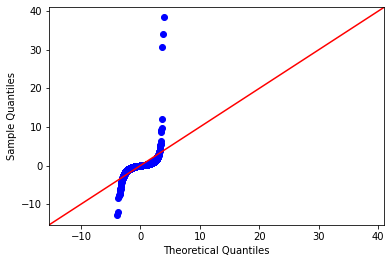

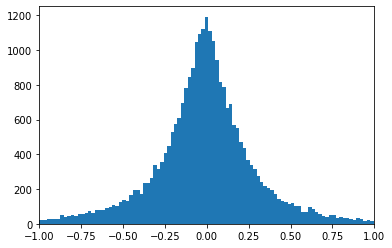

In [14]:
reg.getResidualAnalysis()

# Active and Inactive Stocks Parameters Comparison

In [15]:
out = reg.getActivityAnalysis()
print('active stocks')
print('eta   =', out[0][0])
print('beta  =', out[0][1])
print('\ninactive stocks')
print('eta   =', out[1][0])
print('beta  =', out[1][1])

active stocks
eta   = 10.523729168141966
beta  = 0.8800378313059297

inactive stocks
eta   = 3.2514765747210563
beta  = 1.1189530359002875
